# **Prequisites**


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Importings**

## Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.svm import SVC

import tensorflow as tf

from tensorflow.keras.layers import Dense, Input, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer, LabelEncoder

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,5)

## Dataset

In [3]:
base_dir = '/content/drive/My Drive/power_transformer_fault_diagnosis/datasets/'
df = pd.read_csv(base_dir + 'Kaggle Transformer Dataset.csv')
df

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,15,227,52900,3,60,853,3,84,0,0.0,1.00,32,56,28,13.4,51.0
466,15,334,47100,3,64,622,3,108,0,0.0,1.00,32,55,12,13.4,51.0
467,15,1280,35000,2,675,2530,0,0,0,5.0,0.30,45,58,8,13.4,6.5
468,15,169,50600,5,77,532,0,72,0,0.0,1.21,33,54,11,13.4,51.0


# **Peseudo-Labeling using Duval Triangle**

In [4]:
def duval_triangle(ch4_relative, c2h4_relative, c2h2_relative):

  if ch4_relative >= 98: status = 'PD'
  elif ch4_relative < 98 and c2h4_relative < 20 and c2h2_relative < 4: status = 'T1'
  elif 50 > c2h4_relative >= 20 and c2h2_relative < 4: status = 'T2'
  elif c2h4_relative >= 50 and c2h2_relative < 15: status = 'T3'
  elif c2h4_relative < 50 and 13 > c2h2_relative >= 4: status = 'DT'
  elif 40 <= c2h4_relative < 50 and 29 > c2h2_relative >= 13: status = 'DT'
  elif 50 <= c2h4_relative and 29 > c2h2_relative >= 15: status = 'DT'
  elif 23 < c2h4_relative and c2h2_relative >= 13: status = 'D1'
  elif 23 <= c2h4_relative and c2h2_relative >= 29: status = 'D2'
  elif 23 <= c2h4_relative < 40 and 29 > c2h2_relative >= 13: status = 'D2'
  else: status = 'other'

  return status

In [5]:
duval_state = []

for index, row in df.iterrows():

  ch4_relative = row['Methane']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100
  c2h4_relative = row['Ethylene']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100
  c2h2_relative = row['Acethylene']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100

  duval_state.append(duval_triangle(ch4_relative, c2h4_relative, c2h2_relative))

/tmp/ipykernel_17557/3837557255.py:5: RuntimeWarning: invalid value encountered in scalar divide
  ch4_relative = row['Methane']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100
/tmp/ipykernel_17557/3837557255.py:6: RuntimeWarning: invalid value encountered in scalar divide
  c2h4_relative = row['Ethylene']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100
/tmp/ipykernel_17557/3837557255.py:7: RuntimeWarning: invalid value encountered in scalar divide
  c2h2_relative = row['Acethylene']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100


In [6]:
df['duval_state'] = duval_state
df

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation,duval_state
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0,T3
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0,PD
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0,other
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0,PD
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0,T1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,15,227,52900,3,60,853,3,84,0,0.0,1.00,32,56,28,13.4,51.0,T3
466,15,334,47100,3,64,622,3,108,0,0.0,1.00,32,55,12,13.4,51.0,T3
467,15,1280,35000,2,675,2530,0,0,0,5.0,0.30,45,58,8,13.4,6.5,PD
468,15,169,50600,5,77,532,0,72,0,0.0,1.21,33,54,11,13.4,51.0,PD


In [7]:
df['duval_state'].value_counts()

,count
duval_state,
PD,166
T3,153
other,63
T2,58
T1,16
D1,8
DT,6


In [8]:
labelencoder= LabelEncoder()
df['duval_state_encoded'] = labelencoder.fit_transform(df['duval_state'])

In [9]:
df

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation,duval_state,duval_state_encoded
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0,T3,5
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0,PD,2
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0,other,6
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0,PD,2
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0,T1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,15,227,52900,3,60,853,3,84,0,0.0,1.00,32,56,28,13.4,51.0,T3,5
466,15,334,47100,3,64,622,3,108,0,0.0,1.00,32,55,12,13.4,51.0,T3,5
467,15,1280,35000,2,675,2530,0,0,0,5.0,0.30,45,58,8,13.4,6.5,PD,2
468,15,169,50600,5,77,532,0,72,0,0.0,1.21,33,54,11,13.4,51.0,PD,2


# **Data Preprocessing and Preparation**

## Train/Test Split

In [10]:
df_train, df_test = train_test_split(df, test_size=0.25, random_state=25)

## Target / Feature Declaration

In [11]:
x_train = df_train.iloc[:, :14]
y_train = df_train.iloc[:, [14,15]]
z_train = df_train.iloc[:, -1]

x_test = df_test.iloc[:, :14]
y_test = df_test.iloc[:, [14,15]]
z_test = df_test.iloc[:, -1]

In [12]:
x_train

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3
336,7,492,9748,1,54,221,0,0,0,1.0,0.46,47,66,3
290,22,1220,49900,3,30,813,5,291,0,0.0,1.00,32,57,27
363,5,15700,60200,10,507,5330,19,14,0,0.0,19.70,40,55,17
97,0,944,58700,6,266,3530,8,11,0,153.0,0.35,40,56,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,4,9600,55200,7,785,2690,0,0,0,0.0,1.00,33,57,14
317,8,5570,22800,2,323,989,0,0,0,0.0,1.00,32,38,24
143,4,279,20000,8,285,4230,0,4,0,2.0,0.22,44,55,3
318,8,8470,44500,3,318,569,12,0,0,0.0,1.00,32,51,18


In [13]:
y_train

,Health index,Life expectation
4,85.2,6.0
336,13.4,51.0
290,13.4,51.0
363,13.4,51.0
97,48.2,17.9
...,...,...
374,13.4,51.0
317,13.4,51.0
143,38.3,19.0
318,13.4,51.0


In [14]:
z_train

,duval_state_encoded
4,3
336,2
290,5
363,5
97,5
...,...
374,2
317,2
143,2
318,5


## Scaling

In [15]:
feature_scaler = MinMaxScaler()
feature_scaler.fit(x_train)
x_train_scaled = feature_scaler.transform(x_train)
x_test_scaled = feature_scaler.transform(x_test)

In [16]:
x_train_scaled.shape

(352, 14)

In [17]:
target_scaler = MinMaxScaler()
target_scaler.fit(y_train)
y_train_scaled = target_scaler.transform(y_train)
y_test_scaled = target_scaler.transform(y_test)

In [18]:
y_train_scaled.shape

(352, 2)

## Label Binarizer

In [19]:
z_train_bin = LabelBinarizer().fit_transform(y = z_train)
z_test_bin = LabelBinarizer().fit_transform(y = z_test)

# **SVM Training**

In [20]:
clf = SVC(gamma = 'auto', kernel = 'sigmoid', probability=True)
clf.fit(x_train_scaled, z_train)

SVC(gamma='auto', kernel='sigmoid', probability=True)

In [21]:
from tabulate import tabulate
print(tabulate([
    ['Training Accuracy: ', clf.score(x_train_scaled, z_train)],
    ['Testing Accuracy: ', clf.score(x_test_scaled, z_test)],
]))

------------------  --------
Training Accuracy:  0.346591
Testing Accuracy:   0.262712
------------------  --------


In [22]:
z_train_prob = clf.predict_proba(x_train_scaled)
z_test_prob = clf.predict_proba(x_test_scaled)

In [23]:
z_train_prob.shape

(352, 7)

# **ANN Training**

In [24]:
x_train_added_scaled = np.concatenate([x_train_scaled, z_train_prob], axis = 1)
x_train_added_scaled.shape

(352, 21)

In [25]:
x_test_added_scaled = np.concatenate([x_test_scaled, z_test_prob], axis = 1)
x_test_added_scaled.shape

(118, 21)

In [26]:
def model_creator():

  input = Input(shape=(21,), name='input')
  emb = Dense(units = 16, activation='tanh', name = 'HL1',)(input)
  emb = Dense(units = 11, activation='tanh', name = 'HL2',)(emb)
  # emb = Dense(units = 6, activation='tanh', name = 'HL3',)(emb)
  # emb = Dense(units = 8, activation='tanh', name = 'HL4',)(emb)
  # emb = Dense(units = 8, activation='tanh', name = 'HL5',)(emb)
  predicted_values = Dense(units = 2, activation='tanh', name='values')(emb)

  return Model(inputs = input, outputs = predicted_values)

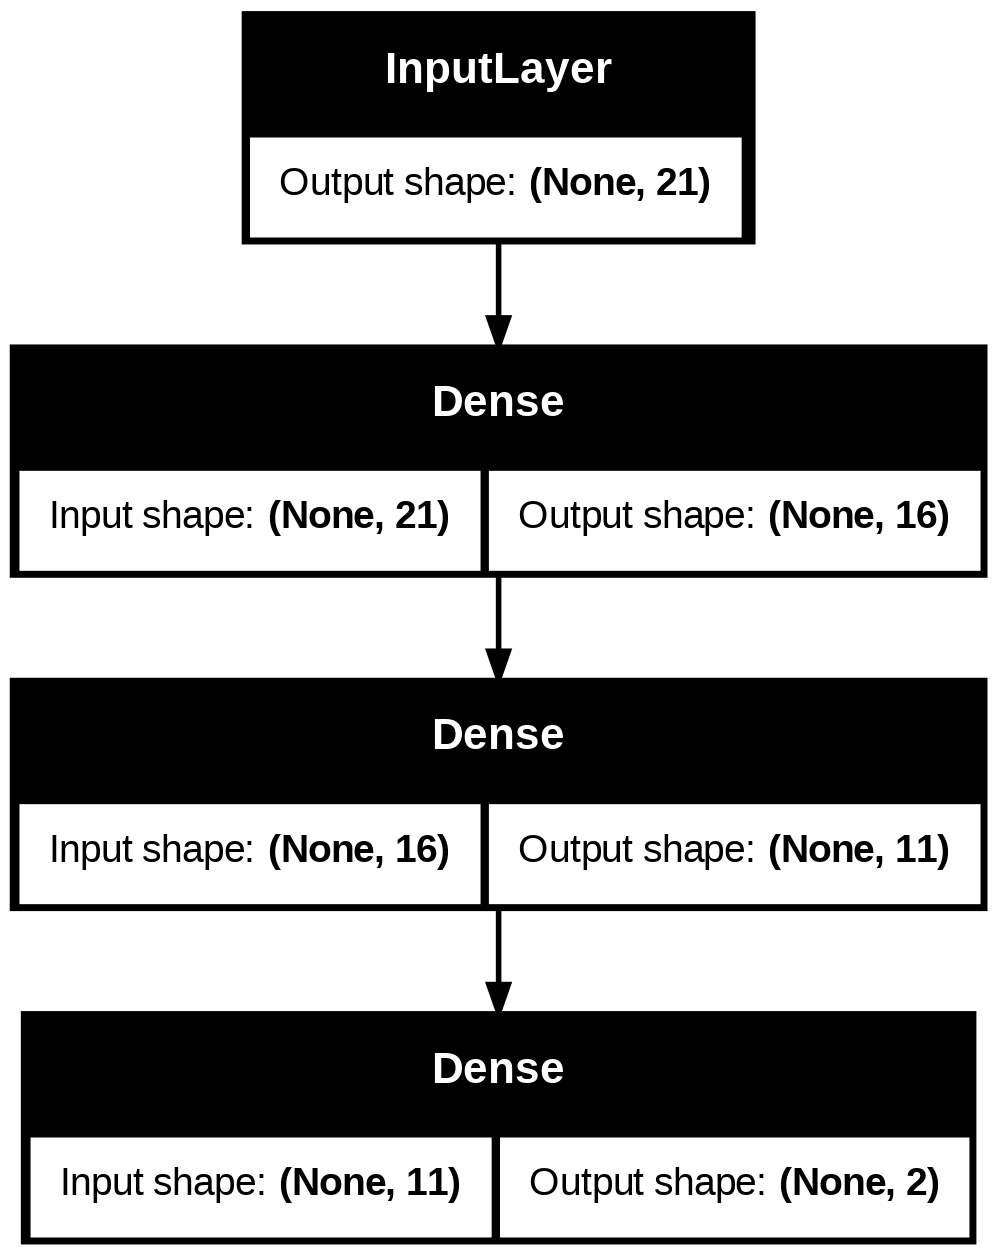

In [27]:
model = model_creator()
plot_model(model, show_shapes = True)

In [28]:
class SaveBestModel(tf.keras.callbacks.Callback):
    def __init__(self, save_best_metric='val_loss', this_max=False):
        self.save_best_metric = save_best_metric
        self.max = this_max
        if this_max:
            self.best = float('-inf')
        else:
            self.best = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        metric_value = logs[self.save_best_metric]
        if self.max:
            if metric_value > self.best:
                self.best = metric_value
                self.best_weights = self.model.get_weights()

        else:
            if metric_value < self.best:
                self.best = metric_value
                self.best_weights= self.model.get_weights()

In [29]:
best_model_saver = SaveBestModel('val_loss')

model = model_creator()

lr = 0.001
ep = 1000
opt = optimizers.Adam(learning_rate=lr, decay=lr / ep)

model.compile(loss = 'mse', optimizer=opt)

history  = model.fit(x = x_train_added_scaled, y = y_train_scaled,
                     validation_split = 0.25, epochs = ep, callbacks=[best_model_saver])

model.set_weights(best_model_saver.best_weights)

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.2893 - val_loss: 0.1656
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1492 - val_loss: 0.1017
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1202 - val_loss: 0.1008
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1203 - val_loss: 0.0968
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1140 - val_loss: 0.0894
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1090 - val_loss: 0.0868
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1073 - val_loss: 0.0853
Epoch 8/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1057 - val_loss: 0.0837
Epoch 9/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1041 - val_loss: 0.0825
Epoch 10/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1025 - val_loss: 0.0815
Epoch 11/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1010 - val_loss: 0.0804
Epoch 12/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0993 - val_los

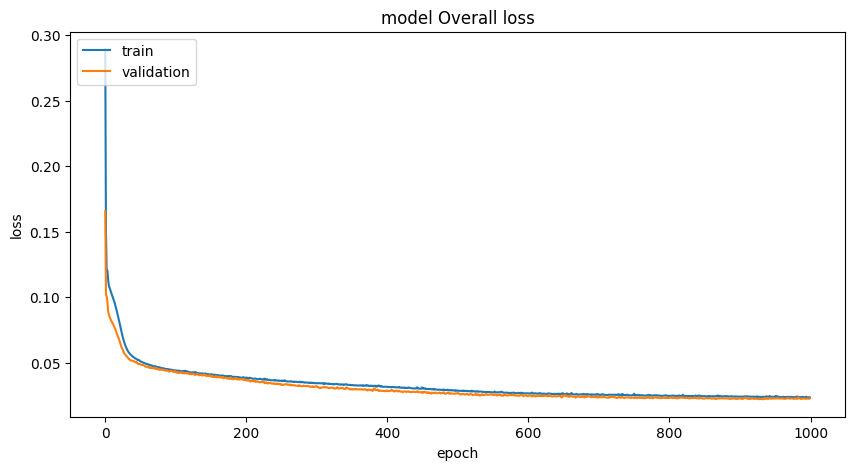

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model Overall loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# **Model Evaluation**

In [31]:
y_train_pred = model.predict(x_train_added_scaled)
y_test_pred = model.predict(x_test_added_scaled)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


## Regression

### MSE Loss

In [32]:
from sklearn.metrics import mean_squared_error

mse_losses = {
    'train': mean_squared_error(y_train_pred, y_train_scaled),
    'test': mean_squared_error(y_test_pred, y_test_scaled)}

mse_losses

{'train': 0.0232673026898395, 'test': 0.04506950888972347}

### MAE Loss

In [33]:
from sklearn.metrics import mean_absolute_error
mae_losses_both = {
    'train': mean_absolute_error(y_train_pred, y_train_scaled),
    'test': mean_absolute_error(y_test_pred, y_test_scaled)}

mae_losses_both

{'train': 0.10020825061605064, 'test': 0.1300169228623662}

In [34]:
mae_losses_health_index = {
    'train': mean_absolute_error(y_train_pred[:, 0], y_train_scaled[:, 0]),
    'test': mean_absolute_error(y_test_pred[:, 0], y_test_scaled[:, 0])}

mae_losses_health_index

{'train': 0.09090713551996182, 'test': 0.09856389457160124}

In [35]:
mae_losses_life_expectation = {
    'train': mean_absolute_error(y_train_pred[:, 1], y_train_scaled[:, 1]),
    'test': mean_absolute_error(y_test_pred[:, 1], y_test_scaled[:, 1])}

mae_losses_life_expectation

{'train': 0.10950936571213964, 'test': 0.16146995115313123}

In [36]:
target_scaler.inverse_transform(y_train_pred)[:, 0]

array([48.594456 , 21.756935 , 13.920354 , 22.702078 , 50.986584 ,
       12.298521 , 53.103188 , 13.246557 , 12.989975 , 13.266635 ,
       55.331383 , 26.445402 , 49.95931  , 17.018326 , 30.641909 ,
       64.5891   , 14.792002 , 23.74154  , 14.993138 , 16.810646 ,
       54.269485 , 52.703106 , 14.246311 , 19.334375 , 33.597145 ,
       17.55002  , 12.268496 , 55.084805 , 23.878935 , 14.608717 ,
       19.247314 , 13.462042 , 13.377274 , 14.298827 , 16.216549 ,
       12.297163 , 25.214354 , 25.083988 , 29.603786 , 21.465807 ,
       65.090935 , 52.45563  , 28.132616 , 12.675918 , 14.031186 ,
       35.283993 , 19.187529 , 66.52525  , 12.254146 , 19.536253 ,
       25.205273 , 13.449887 , 24.490057 , 14.666707 , 33.702362 ,
       14.691033 , 22.460934 , 21.630054 , 51.412617 , 25.989332 ,
       51.845886 , 15.039923 , 27.33513  , 19.623196 , 31.845078 ,
       32.06073  , 14.612501 , 50.50064  , 21.855064 , 57.89147  ,
       31.471476 , 49.461277 , 12.933785 , 40.473373 , 14.4322

In [37]:
np.unique(z_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6]), array([  8,   5, 121,  12,  40, 122,  44]))

In [38]:
np.unique(z_test, return_counts=True)

(array([1, 2, 3, 4, 5, 6]), array([ 1, 45,  4, 18, 31, 19]))

In [39]:
def get_angles(labels_to_convert, all_unique_classes):
    """
    Transforms labels into angles (radians) for a polar plot.
    """
    # Ensure all_unique_classes is sorted to maintain consistent mapping
    all_unique_classes = sorted(list(all_unique_classes))
    num_classes = len(all_unique_classes)

    # Create equal spacing between 0 and 2*pi
    angles_for_map = np.linspace(0, 2 * np.pi, num_classes, endpoint=False)

    # Create a mapping from each unique class to its corresponding index in angles_for_map
    class_to_index_map = {cls: i for i, cls in enumerate(all_unique_classes)}

    # Map each label in labels_to_convert to its corresponding angle
    return np.array([angles_for_map[class_to_index_map[label]] for label in labels_to_convert])

In [47]:
import matplotlib.patheffects as path_effects

def visualize_dataset_polar_pro_light(labels, feature_values, new_point_label, new_point_feature, label_names):
    """
    An enhanced, light-themed polar visualization with high-readability text.
    """
    all_unique_classes = np.unique(labels)
    angles = get_angles(labels, all_unique_classes)
    new_angle = get_angles([new_point_label], all_unique_classes)[0]

    # --- Style Settings ---
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

    # 1) White background
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    # 1. Draw radial 'spokes' for each class (Darker for light theme)
    spoke_angles = np.linspace(0, 2 * np.pi, len(all_unique_classes), endpoint=False)
    for angle in spoke_angles:
        ax.plot([angle, angle], [0, max(feature_values) * 1.1],
                color='black', alpha=0.1, linestyle='--', linewidth=1.2, zorder=1)

    # 2. Plot the dataset (Slightly more opaque for white background)
    scatter = ax.scatter(angles, feature_values, c=labels, cmap='viridis',
                         s=80, alpha=0.8, edgecolors='grey', linewidth=0.5, zorder=3)

    # 3. Highlight the New Point (The 'Hero' element)
    # Using a soft gray glow instead of cyan for the light theme
    ax.scatter(new_angle, new_point_feature, c='black', s=500, marker='o', alpha=0.08, zorder=4)
    ax.scatter(new_angle, new_point_feature, c='#FF3131', s=350, marker='*',
               edgecolors='black', linewidth=1.5, label='New Point', zorder=5)

    # 4. Advanced Formatting & Bigger Text
    ax.set_xticks(spoke_angles)
    # INCREASED: Labels font size to 14
    ax.set_xticklabels(label_names, fontsize=14, fontweight='bold', color='#333333')

    # Clean up the radial grid
    # INCREASED: Tick labels font size to 11
    ax.tick_params(axis='y', colors='#555555', labelsize=11)
    ax.grid(True, color='black', alpha=0.1)

    # Remove the outer spine
    ax.spines['polar'].set_visible(False)

    # 5. Title and Legend
    # INCREASED: Title font size to 20
    plt.title("FEATURE DISTRIBUTION BY CLASS", pad=40, fontsize=20,
              color='black', fontweight='black')

    # INCREASED: Legend font size to 12
    # legend = ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.1), frameon=True, fontsize=12)
    # plt.setp(legend.get_texts(), color='black')
    plt.show()

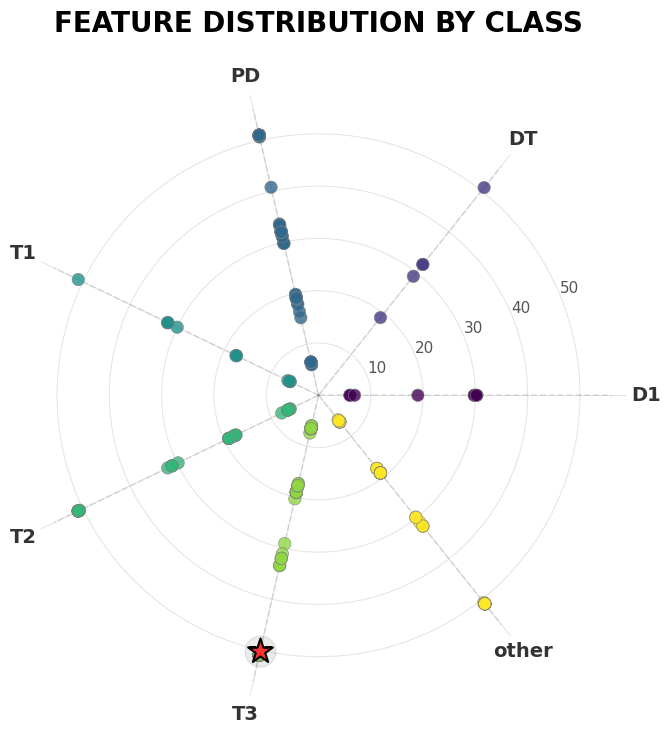

Index: 100
Ground Truth: 50.7 - PD
Predicted: 50.20960235595703 - T3


In [68]:
idx = 100

visualize_dataset_polar_pro_light(z_train, y_train.iloc[:, 1], new_point_label=clf.predict(x_test_scaled)[idx], new_point_feature=target_scaler.inverse_transform(y_test_pred)[idx, 1], label_names=labelencoder.classes_)
print(f"Index: {idx}\nGround Truth: {y_test.iloc[idx, 1]} - {labelencoder.inverse_transform([z_test.iloc[idx]])[0]}\nPredicted: {target_scaler.inverse_transform(y_test_pred)[idx, 1]} - {labelencoder.inverse_transform([clf.predict(x_test_scaled)[idx]])[0]}")

In [50]:
df_test

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation,duval_state,duval_state_encoded
451,17,645,49600,6,87,599,5,211,0,0.0,4.46,33,56,19,13.4,51.0,T2,4
398,3,220,54300,2,24,246,0,153,0,0.0,1.52,33,48,12,13.4,51.0,PD,2
246,39,1060,50800,4,74,804,5,83,0,0.0,1.00,32,56,58,13.4,51.0,T3,5
254,35,438,53300,3,50,547,0,44,0,0.0,2.59,33,55,13,13.4,51.0,PD,2
447,11,265,50800,2,54,1050,0,63,0,0.0,1.00,30,50,16,13.4,51.0,PD,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,0,19900,43300,0,114,782,0,0,0,4.0,1.33,40,54,6,13.4,19.0,other,6
45,211,249900,62600,148,118,2300,751,103,3030,0.0,1.00,45,41,9,50.6,29.8,other,6
48,216,24300,48500,93,94,1890,578,36,2830,0.0,1.00,42,54,7,50.6,29.9,other,6
112,4,624,44500,36,232,2580,3,54,0,169.0,1.16,42,56,8,48.1,6.5,T1,3
